In [149]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
shaunthesheep_microsoft_catsvsdogs_dataset_path = kagglehub.dataset_download('shaunthesheep/microsoft-catsvsdogs-dataset')

print('Data source import complete.')


Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
Data source import complete.


In [150]:
import os
import shutil
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import random
import plotly.express as px
import scipy as sp

from scipy import ndimage
from shutil import copyfile
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Conv2D,Add,MaxPooling2D, Dense, BatchNormalization,Input, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras.applications.resnet_v2 import preprocess_input


In [151]:
try:
    os.mkdir('/tmp/cats-v-dogs')
    os.mkdir('/tmp/cats-v-dogs/training')
    os.mkdir('/tmp/cats-v-dogs/validation')
    os.mkdir('/tmp/cats-v-dogs/test')
    os.mkdir('/tmp/cats-v-dogs/training/cats')
    os.mkdir('/tmp/cats-v-dogs/training/dogs')
    os.mkdir('/tmp/cats-v-dogs/validation/cats')
    os.mkdir('/tmp/cats-v-dogs/validation/dogs')
    os.mkdir('/tmp/cats-v-dogs/test/cats')
    os.mkdir('/tmp/cats-v-dogs/test/dogs')
except OSError:
    print('Error failed to make directory')

Error failed to make directory


In [152]:
#Define data path
CAT_DIR = os.path.join(shaunthesheep_microsoft_catsvsdogs_dataset_path, 'PetImages/Cat')
DOG_DIR = os.path.join(shaunthesheep_microsoft_catsvsdogs_dataset_path, 'PetImages/Dog')

TRAINING_DIR = "/tmp/cats-v-dogs/training/"
VALIDATION_DIR = "/tmp/cats-v-dogs/validation/"

TRAINING_CATS = os.path.join(TRAINING_DIR, "cats/")
VALIDATION_CATS = os.path.join(VALIDATION_DIR, "cats/")

TRAINING_DOGS = os.path.join(TRAINING_DIR, "dogs/")
VALIDATION_DOGS = os.path.join(VALIDATION_DIR, "dogs/")

# Define whether to include test split or not
INCLUDE_TEST = True

In [153]:
def split_data(main_dir, training_dir, validation_dir, test_dir=None, include_test_split = True,  split_size=0.8):
    """
    Splits the data into train validation and test sets (optional)

    Args:
    main_dir (string):  path containing the images
    training_dir (string):  path to be used for training
    validation_dir (string):  path to be used for validation
    test_dir (string):  path to be used for test
    include_test_split (boolen):  whether to include a test split or not
    split_size (float): size of the dataset to be used for training
    """
    files = []
    for file in os.listdir(main_dir):
        if  os.path.getsize(os.path.join(main_dir, file)): # check if the file's size isn't 0
            files.append(file) # appends file name to a list

    shuffled_files = random.sample(files,  len(files)) # shuffles the data
    split = int(split_size * len(shuffled_files)) #the training split casted into int for numeric rounding
    train = shuffled_files[:split] #training split
    split_valid_test = int(split + (len(shuffled_files)-split)/2)

    if include_test_split:
        validation = shuffled_files[split:split_valid_test] # validation split
        test = shuffled_files[split_valid_test:]
    else:
        validation = shuffled_files[split:]

    for element in train:
        copyfile(os.path.join(main_dir,  element), os.path.join(training_dir, element)) # copy files into training directory

    for element in validation:
        copyfile(os.path.join(main_dir,  element), os.path.join(validation_dir, element))# copy files into validation directory

    if include_test_split:
        for element in test:
            copyfile(os.path.join(main_dir,  element), os.path.join(test_dir, element)) # copy files into test directory
    print("Split successful!")

In [154]:
split_data(CAT_DIR, '/tmp/cats-v-dogs/training/cats', '/tmp/cats-v-dogs/validation/cats', '/tmp/cats-v-dogs/test/cats',INCLUDE_TEST, 0.9)
split_data(DOG_DIR, '/tmp/cats-v-dogs/training/dogs', '/tmp/cats-v-dogs/validation/dogs','/tmp/cats-v-dogs/test/dogs',INCLUDE_TEST, 0.9)

Split successful!
Split successful!


In [155]:
print(len(os.listdir('/tmp/cats-v-dogs/training/cats')))
print(len(os.listdir('/tmp/cats-v-dogs/training/dogs')))
num_train_samples_cats = len(os.listdir('/tmp/cats-v-dogs/training/cats'))
num_train_samples_dogs = len(os.listdir('/tmp/cats-v-dogs/training/dogs'))

print(len(os.listdir('/tmp/cats-v-dogs/validation/cats')))
print(len(os.listdir('/tmp/cats-v-dogs/validation/dogs')))


print(len(os.listdir('/tmp/cats-v-dogs/test/cats')))
print(len(os.listdir('/tmp/cats-v-dogs/test/dogs')))

12500
12500
5361
3737
5111
3776


Create Generators

In [156]:
train_gen = ImageDataGenerator(
        preprocessing_function=preprocess_input
)


validation_gen =  ImageDataGenerator(
        preprocessing_function=preprocess_input
)

if INCLUDE_TEST:
    test_gen = ImageDataGenerator(
        preprocessing_function=preprocess_input
    )


In [157]:
BATCHSIZE = 64
train_generator = train_gen.flow_from_directory(
    TRAINING_DIR,
    target_size=(150, 150),
    batch_size=BATCHSIZE,
    class_mode='binary'   # binary labels 0/1
)

validation_generator = validation_gen.flow_from_directory(
    VALIDATION_DIR,
    target_size=(150, 150),
    batch_size=BATCHSIZE,
    class_mode='binary'
)

if INCLUDE_TEST:
    test_generator = test_gen.flow_from_directory(
        VALIDATION_DIR,
        target_size=(150, 150),
        batch_size=BATCHSIZE,
        class_mode='binary'
    )

Found 24998 images belonging to 2 classes.
Found 9098 images belonging to 2 classes.
Found 9098 images belonging to 2 classes.


In [158]:
class_names = ['Cat', 'Dog']
def plot_data(generator, n_images):
    """
    Plots random data from dataset
    Args:
    generator: a generator instance
    n_images : number of images to plot
    """
    i = 1
    images, labels = next(generator)
    labels = labels.astype('int32')

    plt.figure(figsize=(14, 15))

    for image, label in zip(images, labels):
        plt.subplot(4, 3, i)
        plt.imshow(image)
        plt.title(class_names[label])
        plt.axis('off')
        i += 1
        if i == n_images:
            break

    plt.show()

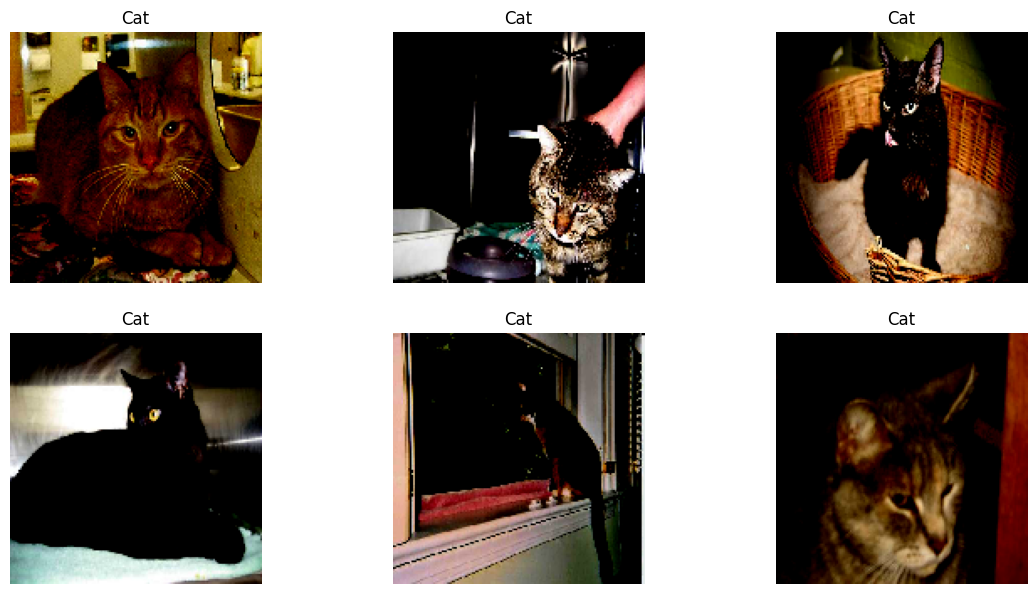

In [159]:
plot_data(train_generator,7)

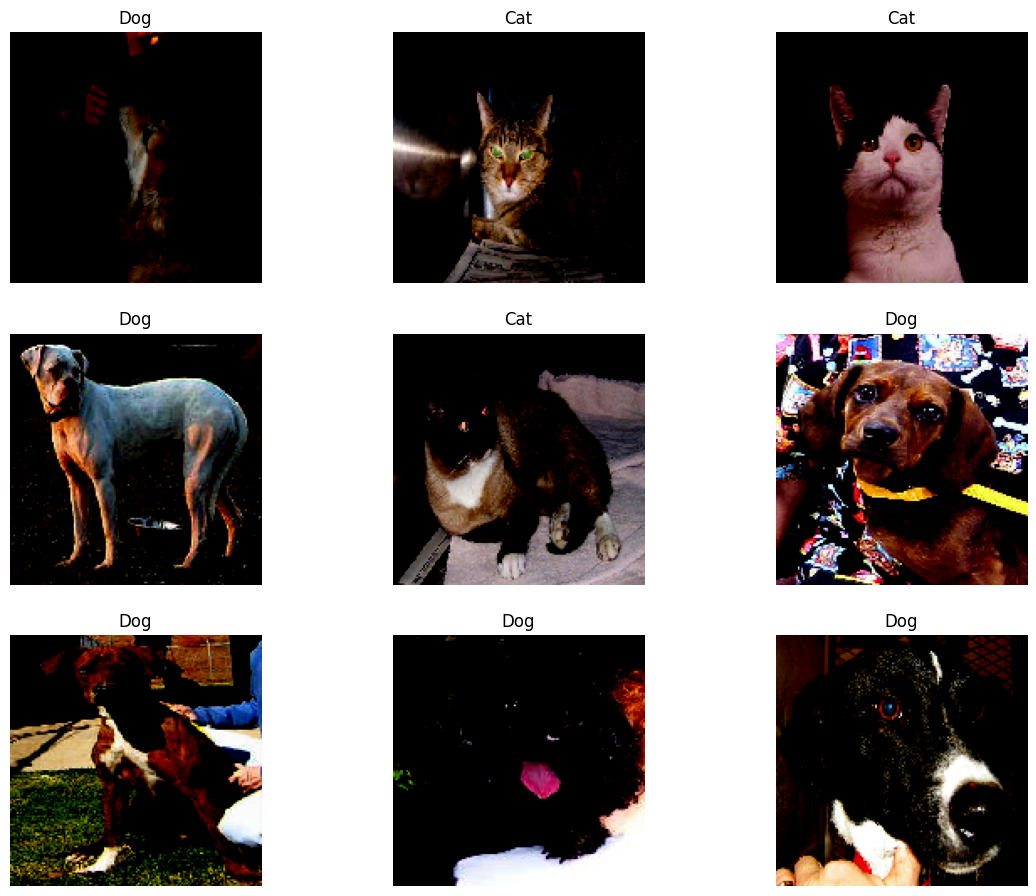

In [160]:
if INCLUDE_TEST:
    plot_data(test_generator, 10)

Build Teacher

In [161]:
IMG_SIZE = (150, 150, 3)
def make_teacher():
    base_model = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=IMG_SIZE
    )

    # Freeze most layers, unfreeze the last block for fine-tuning.
    base_model.trainable = True
    fine_tune_at = 140
    for layer in base_model.layers[:fine_tune_at]:
      layer.trainable = False
    inputs = Input(shape=IMG_SIZE)

    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation='relu')(x)
    x = Dropout(0.5)(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=inputs, outputs=output)
    return model

teacher = make_teacher()
teacher.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
teacher.summary()


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_27 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 5, 5, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,089,601 (91.89 MB)

 Trainable params: 16,877,057 (64.38 MB)

 Non-trainable params: 7,212,544 (27.51 MB)

In [162]:
EPOCHS_TEACHER = 2  # or 10 if you have time

history_teacher = teacher.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_TEACHER,

)

teacher_eval = teacher.evaluate(test_generator)
print("Teacher test loss, acc:", teacher_eval)

teacher.save("teacher_resnet50v2.h5")

Epoch 1/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 105s 217ms/step - accuracy: 0.9075 - loss: 0.1992 - val_accuracy: 0.9955 - val_loss: 0.0202
Epoch 2/2
391/391 ━━━━━━━━━━━━━━━━━━━━ 68s 173ms/step - accuracy: 0.9928 - loss: 0.0242 - val_accuracy: 0.9976 - val_loss: 0.0089
143/143 ━━━━━━━━━━━━━━━━━━━━ 16s 110ms/step - accuracy: 0.9974 - loss: 0.0092


Teacher test loss, acc: [0.008899656124413013, 0.9975818991661072]


Start building baseline student (control)

In [163]:


def make_student_small():
    inputs = layers.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))

    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Flatten()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    model = models.Model(inputs, outputs)
    return model

student_vanilla = make_student_small()
student_vanilla.compile(
    optimizer=Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
student_vanilla.summary()


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_28 (InputLayer)     │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 150, 150, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_63 (MaxPooling2D) │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_64 (MaxPooling2D) │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_65 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 41472)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 128)            │     5,308,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_21 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,401,921 (20.61 MB)

 Trainable params: 5,401,921 (20.61 MB)

 Non-trainable params: 0 (0.00 B)

In [164]:
EPOCHS_STUDENT = 3

history_student_vanilla = student_vanilla.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS_STUDENT,

)

student_vanilla_eval = student_vanilla.evaluate(test_generator)
print("Student (no KD) test loss, acc:", student_vanilla_eval)


Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 63s 153ms/step - accuracy: 0.6252 - loss: 0.6350 - val_accuracy: 0.7577 - val_loss: 0.5064
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 58s 149ms/step - accuracy: 0.7558 - loss: 0.5055 - val_accuracy: 0.7449 - val_loss: 0.5163
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 57s 145ms/step - accuracy: 0.7844 - loss: 0.4626 - val_accuracy: 0.7969 - val_loss: 0.4446
143/143 ━━━━━━━━━━━━━━━━━━━━ 15s 102ms/step - accuracy: 0.7979 - loss: 0.4453
Student (no KD) test loss, acc: [0.4445682764053345, 0.796878457069397]


Begin Knowledge Distillation (Distilled student) (test)

In [170]:
teacher = load_model("teacher_resnet50v2.h5")
teacher.trainable = False
student_kd = make_student_small()

In [172]:
import tensorflow as tf
from tensorflow import keras

class Distiller(keras.Model):
    def __init__(self, student, teacher, temperature=4.0, alpha=0.8):
        super().__init__()
        self.student = student
        self.teacher = teacher
        self.temperature = temperature  # how "soft" teacher probs are (we'll use it as a scaling factor)
        self.alpha = alpha              # weight for hard vs soft loss

        self.student_loss_fn = keras.losses.BinaryCrossentropy()
        # for soft loss, simple MSE between teacher & student probs is okay for this project
        self.distillation_loss_fn = keras.losses.MeanSquaredError()
        self.student_metric = keras.metrics.BinaryAccuracy(name="accuracy")

    def compile(self, optimizer):
        super().compile(optimizer=optimizer)

    def train_step(self, data):
        x, y_true = data  # x = images, y_true = true labels

        # 1. Teacher predictions (no gradients)
        teacher_probs = tf.stop_gradient(self.teacher(x, training=False))

        with tf.GradientTape() as tape:
            # 2. Student predictions
            student_probs = self.student(x, training=True)

            # 3. Hard loss (true labels)
            hard_loss = self.student_loss_fn(y_true, student_probs)

            # 4. Distillation loss (teacher vs student)
            soft_loss = self.distillation_loss_fn(teacher_probs, student_probs)

            # 5. Total loss: blend them
            loss = self.alpha * hard_loss + (1.0 - self.alpha)* (self.temperature**2) * soft_loss

        # 6. Backprop ONLY through student
        trainable_vars = self.student.trainable_variables
        grads = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(grads, trainable_vars))

        # 7. Update metrics
        self.student_metric.update_state(y_true, student_probs)

        return {
            "loss": loss,
            "hard_loss": hard_loss,
            "soft_loss": soft_loss,
            "accuracy": self.student_metric.result(),
        }

    def test_step(self, data):
        x, y_true = data
        student_probs = self.student(x, training=False)
        hard_loss = self.student_loss_fn(y_true, student_probs)
        self.student_metric.update_state(y_true, student_probs)
        return {
            "loss": hard_loss,
            "accuracy": self.student_metric.result(),
        }


In [173]:
distiller = Distiller(
    student=student_kd,
    teacher=teacher,
    temperature=4.0,
    alpha=0.8 # the smaller the alpha, the more the teacher's teachings is taken into account
)

distiller.compile(
    optimizer=Adam(1e-4)
)

history_kd = distiller.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=3
)

kd_eval = distiller.evaluate(test_generator)
print("KD student test loss, acc:", kd_eval)


Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 78s 178ms/step - accuracy: 0.6157 - hard_loss: 0.6038 - loss: 1.1404 - soft_loss: 0.2054 - val_accuracy: 0.7587 - val_loss: 0.0000e+00
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 65s 165ms/step - accuracy: 0.7466 - hard_loss: 0.5040 - loss: 0.9257 - soft_loss: 0.1633 - val_accuracy: 0.7960 - val_loss: 0.0000e+00
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 63s 162ms/step - accuracy: 0.7866 - hard_loss: 0.4519 - loss: 0.8174 - soft_loss: 0.1425 - val_accuracy: 0.8239 - val_loss: 0.0000e+00
143/143 ━━━━━━━━━━━━━━━━━━━━ 14s 97ms/step - accuracy: 0.8227 - loss: 0.3961
KD student test loss, acc: [0.0, 0.8239173293113708]


In [168]:
print("Teacher params:", teacher.count_params())
print("Student (vanilla) params:", student_vanilla.count_params())
print("Student (KD) params:", student_kd.count_params())


Teacher params: 24089601
Student (vanilla) params: 5401921
Student (KD) params: 5401921


In [169]:
teacher.save("teacher.h5")
student_vanilla.save("student_vanilla.h5")
student_kd.save("student_kd.h5")

import os
print("Teacher file size (MB):", os.path.getsize("teacher.h5") / 1e6)
print("Student vanilla size (MB):", os.path.getsize("student_vanilla.h5") / 1e6)
print("Student KD size (MB):", os.path.getsize("student_kd.h5") / 1e6)


Teacher file size (MB): 96.744456
Student vanilla size (MB): 64.869968
Student KD size (MB): 21.638936
